# 1주차 실습 · 작은 단서가 분류가 되기까지
**관찰 → 예상 → 한 값 변경 → 실행 → 근거 설명**

사람은 컵의 테두리와 손잡이 같은 단서로 물체를 알아봅니다. 컴퓨터는 픽셀에서 어떤 차이를 계산할 수 있을까요?
이 노트북에서는 사람이 정한 필터를 먼저 관찰하고, 작은 CNN이 예시로부터 필터를 학습하는 과정까지 연결합니다.

| 진행 | 강의 연결 | 활동 | 시간 |
|---|---|---|---|
| 핵심 0–3 | PDF 13–18, 24–25쪽 | 경계 손계산·필터·이동·풀링 | 15분 |
| 확장 4–6 | PDF 19–23쪽 | CNN 학습·특징 맵·오분류 | 20–30분 |
| 정리 7 | PDF 26쪽 | 관찰 기록 저장·자율 실험 | 5분 이상 |

**90분 수업에서는 종이 활동 15분을 핵심 0–3으로 교체**합니다. 확장은 별도 시간에 진행합니다.
Colab에서 `런타임 → 모두 실행`하거나 위에서 아래로 실행하세요. 필요한 패키지는 torch, numpy, matplotlib이며
Colab 기본 환경의 설치본을 사용합니다. 로컬에서 없으면 `%pip install torch numpy matplotlib`를 별도 셀에서 실행하세요.
GPU·계정·외부 데이터·다른 노트북은 필요 없습니다. 실행 출력이 저장되어 있어 실행 전에도 예시를 읽을 수 있습니다.

도형은 수업용 합성 데이터이며 실제 사물 인식이나 인간 시각을 재현한 데이터가 아닙니다.

## 0. 준비 · 1분
아래 두 셀은 실행만 합니다. 보조 함수의 코드를 모두 읽을 필요는 없습니다.

In [1]:
import copy, json, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import display, Markdown

# 이 작은 실험은 GPU 없이 실행합니다. 그림 속 영문은 폰트 설치를 피하기 위한 표기입니다.
torch.set_num_threads(min(4, torch.get_num_threads()))
DEVICE = torch.device('cpu')
SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.facecolor': '#f4f2e9',
    'figure.facecolor': '#faf9f5', 'axes.prop_cycle': plt.cycler(color=['#187a70','#dd7046','#596ba5'])})
NAMES = ['circle', 'square']
print('PyTorch', torch.__version__, '| device:', DEVICE)

PyTorch 2.14.0+cpu | device: cpu


In [2]:
def make_objects(n, seed):
    """서로 다른 seed로 연속적인 위치·크기·잡음을 생성합니다. 라벨 0=원, 1=정사각형."""
    assert n % 2 == 0
    rng = np.random.default_rng(seed)
    y = np.tile([0, 1], n // 2); rng.shuffle(y)
    yy, xx = np.mgrid[:28, :28].astype('float32')
    masks = []
    for label in y:
        cx, cy = rng.uniform(11, 17, 2)
        radius = rng.uniform(5, 8)
        dx, dy = xx-cx, yy-cy
        # 넓이만으로 분류하지 못하도록 사각형의 반폭을 조절합니다.
        half = radius * np.sqrt(np.pi) / 2
        mask = dx*dx + dy*dy <= radius*radius if label == 0 else (abs(dx) <= half) & (abs(dy) <= half)
        masks.append(mask)
    masks = torch.tensor(np.stack(masks), dtype=torch.float32).unsqueeze(1)
    noise = torch.tensor(rng.normal(0, .025, (n, 1, 28, 28)), dtype=torch.float32)
    return masks, torch.tensor(y, dtype=torch.long), noise

def grayscale(objects):
    mask, _, noise = objects
    return (.12 + .76*mask + noise).clamp(0, 1)

def gallery(images, labels=None, titles=None, n=8):
    n = min(n, len(images))
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.4), squeeze=False)
    for i, ax in enumerate(axes[0]):
        img = images[i].detach().cpu()
        if img.shape[0] == 1:
            ax.imshow(img[0], cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(img.permute(1,2,0).clamp(0,1))
        if titles is not None: ax.set_title(titles[i], fontsize=9)
        elif labels is not None: ax.set_title(NAMES[int(labels[i])])
        ax.axis('off')
    plt.tight_layout(); plt.show()

class SmallCNN(nn.Module):
    def __init__(self, channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Linear(16*7*7, 2)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    logits = model(x.to(DEVICE)).cpu()
    pred = logits.argmax(1)
    cm = torch.bincount(2*y + pred, minlength=4).reshape(2,2)
    return {'accuracy': float((pred == y).float().mean()),
            'loss': float(F.cross_entropy(logits,y)), 'cm': cm, 'logits': logits}

def train_model(x, y, vx, vy, epochs, seed=None):
    # 호출할 때마다 같은 초기값, 같은 배치 순서로 새 모델을 만듭니다.
    seed = SEED if seed is None else seed
    torch.manual_seed(seed)
    model = SmallCNN(x.shape[1]).to(DEVICE)
    before = copy.deepcopy(model.state_dict())
    optimizer = torch.optim.Adam(model.parameters(), lr=.003)
    order_rng = torch.Generator().manual_seed(seed + 100)
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train(); total = 0.
        for ix in torch.randperm(len(y), generator=order_rng).split(64):
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x[ix].to(DEVICE)), y[ix].to(DEVICE))
            assert torch.isfinite(loss), '손실이 유한한지 확인하세요.'
            loss.backward(); optimizer.step()
            total += float(loss.detach()) * len(ix)
        val = evaluate(model, vx, vy)
        history['train_loss'].append(total/len(y))
        history['val_loss'].append(val['loss'])
        history['val_accuracy'].append(val['accuracy'])
        if epoch == 0 or epoch == epochs-1:
            print(f"epoch {epoch+1:2d}/{epochs} | train CE {total/len(y):.3f} | val acc {val['accuracy']:.3f}")
    assert not torch.equal(before['features.0.weight'], model.features[0].weight.detach().cpu())
    print(f'elapsed: {time.perf_counter()-start:.1f}s')
    # epoch 수는 test를 보기 전에 고정합니다. 최종 epoch 모델로 평가합니다.
    return model, history, before

def show_history(history):
    fig, axes = plt.subplots(1,2,figsize=(10,3))
    epochs = np.arange(1, len(history['train_loss'])+1)
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='validation')
    axes[0].set(xlabel='epoch', ylabel='cross entropy'); axes[0].legend()
    axes[1].plot(epochs, history['val_accuracy'])
    axes[1].set(xlabel='epoch', ylabel='validation accuracy', ylim=(0,1.05))
    plt.tight_layout(); plt.show()

## 1. “오른쪽이 밝다”를 숫자로 말하기 · 4분
**실행 전 예상:** 3×3 필터의 각 행이 `[-1, 0, 1]`이면 왼쪽과 오른쪽이 같은 곳, 밝아지는 경계, 어두워지는 경계에서 각각 어떤 부호가 나올까요?
세로 경계는 좌우 밝기 차이로 찾습니다. 여기서 사용하는 연산은 PyTorch Conv2d의 교차상관 방식입니다.

In [3]:
toy = torch.tensor([[0,0,1,1,1]]*5, dtype=torch.float32)
kernel = torch.tensor([[-1,0,1]]*3, dtype=torch.float32)
# 바꿔 볼 곳: ROW, COL을 각각 0, 1, 2 중 선택합니다.
ROW, COL = 0, 0
assert 0 <= ROW <= 2 and 0 <= COL <= 2
patch = toy[ROW:ROW+3, COL:COL+3]
manual = (patch*kernel).sum()
response = F.conv2d(toy[None,None], kernel[None,None])[0,0]
print('입력 조각:\n', patch.numpy(), '\n원소별 곱:\n', (patch*kernel).numpy())
print('손계산 합:', float(manual), '| 전체 특징 맵:\n', response.numpy())
assert torch.isclose(manual, response[ROW,COL])
assert torch.equal(response, torch.tensor([[3.,3.,0.]]*3))

입력 조각:
 [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]] 
원소별 곱:
 [[-0.  0.  1.]
 [-0.  0.  1.]
 [-0.  0.  1.]]
손계산 합: 3.0 | 전체 특징 맵:
 [[3. 3. 0.]
 [3. 3. 0.]
 [3. 3. 0.]]


**직접 해 보기:** `COL=2`로 바꿔 실행하고, 값이 0인 이유를 말해 보세요. 다음 셀에서는 입력을 좌우 반전합니다.
0은 언제나 “아무것도 없음”일까요, 아니면 이 필터가 측정한 좌우 차이가 없다는 뜻일까요?

반전 후 특징 맵:
 [[ 0. -3. -3.]
 [ 0. -3. -3.]
 [ 0. -3. -3.]]


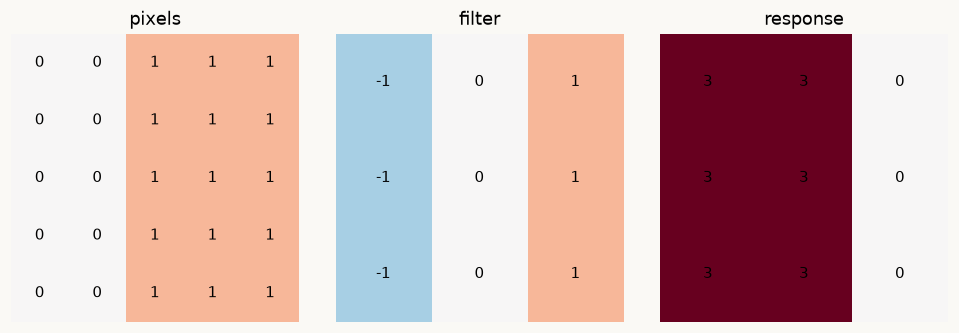

In [4]:
flipped = toy.flip(-1)
flipped_response = F.conv2d(flipped[None,None], kernel[None,None])[0,0]
print('반전 후 특징 맵:\n', flipped_response.numpy())
assert torch.equal(flipped_response, torch.tensor([[0.,-3.,-3.]]*3))
fig, axes = plt.subplots(1,3,figsize=(9,3))
for ax, arr, title in zip(axes, [toy,kernel,response], ['pixels','filter','response']):
    ax.imshow(arr, cmap='RdBu_r', vmin=-3, vmax=3)
    for (r,c), value in np.ndenumerate(arr.numpy()): ax.text(c,r,f'{value:g}',ha='center',va='center')
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. 같은 컵, 다른 단서 · 5분
수직 경계·수평 경계·평균 필터를 같은 이미지에 적용합니다. **예상:** 손잡이의 좌우 가장자리와 몸체의 윗변은 어느 필터에서 잘 보일까요?
우리가 넣은 필터는 수작업 규칙입니다. 뒤의 CNN은 같은 역할의 숫자를 학습으로 바꿉니다.

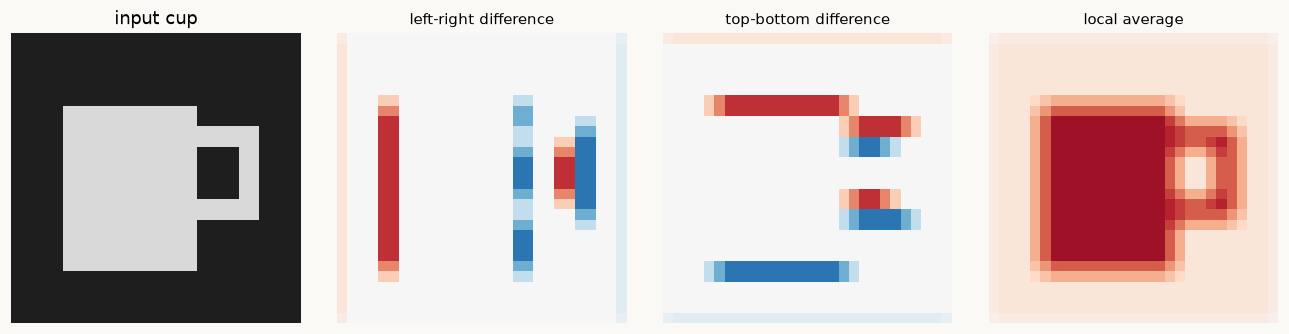

입력: (1, 1, 28, 28) 출력: (1, 3, 28, 28) (batch, channel, height, width)


In [5]:
cup = torch.full((1,1,28,28), .12)
cup[:,:,7:23,5:18] = .85
cup[:,:,9:18,18:24] = .85
cup[:,:,11:16,18:22] = .12
filters = torch.stack([kernel/3, kernel.T/3, torch.ones(3,3)/9])[:,None]
maps = F.conv2d(cup, filters, padding=1)
fig, axes = plt.subplots(1,4,figsize=(12,3))
axes[0].imshow(cup[0,0],cmap='gray',vmin=0,vmax=1); axes[0].set_title('input cup')
for ax, fmap, name in zip(axes[1:], maps[0], ['left-right difference','top-bottom difference','local average']):
    ax.imshow(fmap, cmap='RdBu_r',vmin=-1,vmax=1); ax.set_title(name,fontsize=10)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print('입력:', tuple(cup.shape), '출력:', tuple(maps.shape), '(batch, channel, height, width)')

**한 값 변경:** 아래 `CHANNEL`을 0, 1, 2로 바꿔 ReLU와 풀링 전후를 비교합니다.
음수 반응을 없애면 어떤 방향의 경계 정보가 사라질까요? 풀링은 세부 위치를 얼마나 남길까요?

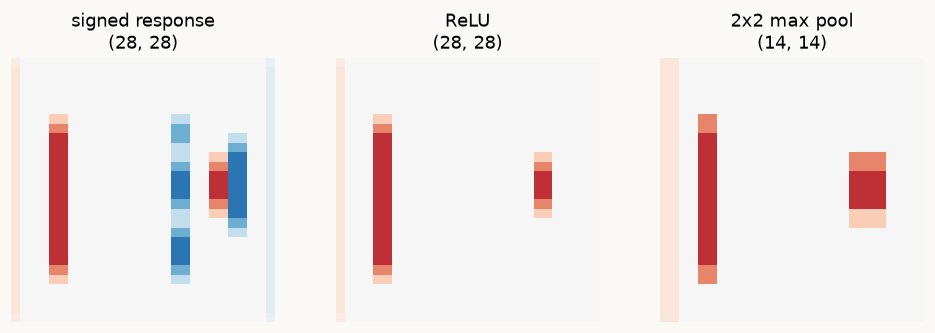

In [6]:
CHANNEL = 0
assert CHANNEL in (0,1,2)
chosen = maps[:,CHANNEL:CHANNEL+1]
activated = F.relu(chosen)
pooled = F.max_pool2d(activated, 2)
fig, axes = plt.subplots(1,3,figsize=(9,3))
for ax, value, title in zip(axes,[chosen,activated,pooled],['signed response','ReLU','2x2 max pool']):
    ax.imshow(value[0,0], cmap='RdBu_r',vmin=-1,vmax=1)
    ax.set_title(f'{title}\n{tuple(value.shape[-2:])}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 3. 물체가 움직이면 특징도 움직일까? · 5분
CNN의 공유 필터는 같은 패턴을 다른 위치에서도 계산합니다. 이것은 **특징 맵이 함께 이동하는 등변성**의 직관입니다.
**분류 결과가 같다는 불변성**과 구분합니다. 유한 이미지의 경계·stride·pooling은 이 관계를 깨뜨릴 수 있습니다.

경계 제외: 필터→이동 vs 이동→필터 최대 차이 = 0.0


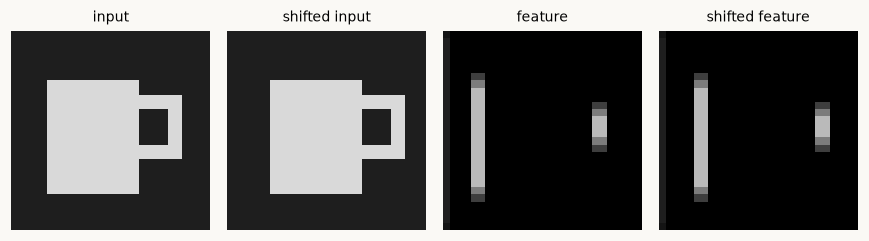

풀링 맵이 완전히 같은가? False


In [7]:
# 오른쪽으로 1칸 또는 2칸 이동합니다. torch.roll의 반대편 감김을 쓰지 않습니다.
SHIFT = 1
assert SHIFT in (1,2)
def shift_right(x, amount, fill=0.):
    out = torch.full_like(x, fill)
    out[...,amount:] = x[...,:-amount]
    return out

moved = shift_right(cup, SHIFT, .12)
a = F.relu(F.conv2d(cup, filters[:1], padding=1))
b = F.relu(F.conv2d(moved, filters[:1], padding=1))
expected = shift_right(a, SHIFT)
# 이미지 경계를 제외하고, 두 연산 순서의 일치 여부를 수치로 확인합니다.
inner = (..., slice(3,-3), slice(4,-3))
error = float((b[inner]-expected[inner]).abs().max())
assert error < 1e-6
print('경계 제외: 필터→이동 vs 이동→필터 최대 차이 =', error)
gallery(torch.cat([cup,moved,a,b]), titles=['input','shifted input','feature','shifted feature'], n=4)
pa,pb = F.max_pool2d(a,2), F.max_pool2d(b,2)
print('풀링 맵이 완전히 같은가?', bool(torch.allclose(pa,pb)))

### 핵심 활동 기록 · 여기까지가 15분 수업 범위
| 질문 | 내 관찰과 근거 |
|---|---|
| `COL=0`과 `COL=2`에서 값이 다른 이유 | 여기에 작성 |
| 반전했을 때 부호가 바뀌는 이유 | 여기에 작성 |
| ReLU/풀링이 버린 정보 | 여기에 작성 |
| 등변성과 분류 불변성의 차이 | 여기에 작성 |

**자가 확인:** 0인 반응은 물체가 없다는 뜻이 아닙니다. 특징 맵이 이동했다고 최종 분류도 항상 같다고 결론 내릴 수 없습니다.

## 4. 필터를 사람이 정하지 않으면? · 확장 10분
원/정사각형의 경계를 구분하는 CNN을 학습합니다. 위치·크기·잡음은 바뀌고 면적은 비슷하도록 만듭니다.
train은 가중치 조정, validation은 학습 관찰, test는 고정한 실험의 마지막 평가에 사용합니다.
서로 다른 seed로 생성한 세 집합이며 같은 이미지 파일을 나누는 방식이 아닙니다.

**실행 전 예상:** 랜덤 필터가 어느 방향으로 바뀔지 구체적인 이름까지 예측할 수 있을까요?

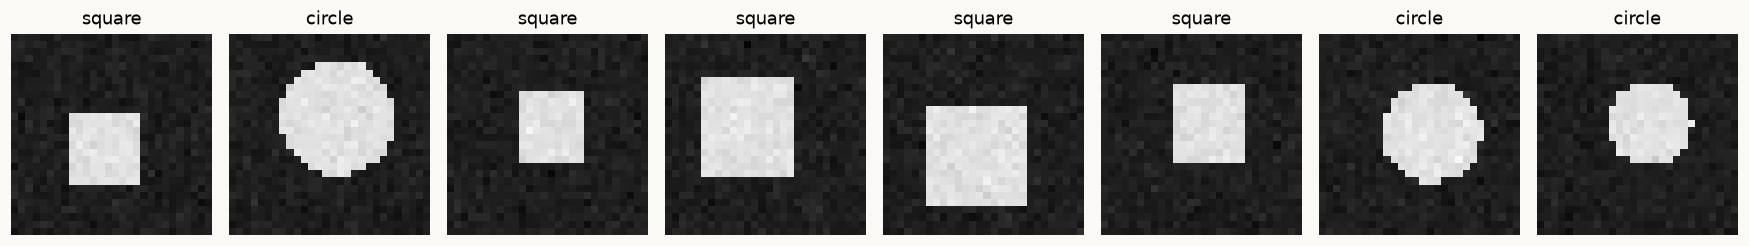

train / val / test: 768 192 192


In [8]:
# 변경 후 이 셀부터 다시 실행합니다. epoch는 test 결과를 보기 전에 정합니다.
EPOCHS = 10
train_objects = make_objects(768, 101)
val_objects = make_objects(192, 202)
test_objects = make_objects(192, 303)
x_train, y_train = grayscale(train_objects), train_objects[1]
x_val, y_val = grayscale(val_objects), val_objects[1]
x_test, y_test = grayscale(test_objects), test_objects[1]
gallery(x_train, y_train)
print('train / val / test:', len(y_train), len(y_val), len(y_test))

다음 셀은 모델 생성과 학습을 한 번에 실행합니다. 손실은 정답 점수를 더 높이도록 가중치를 조정하는 기준입니다.
**할 일:** 첫 epoch와 마지막 epoch의 손실·검증 정확도를 비교하세요. test 결과에 맞춰 epoch를 골라서는 안 됩니다.

epoch  1/10 | train CE 0.689 | val acc 0.500


epoch 10/10 | train CE 0.024 | val acc 1.000
elapsed: 0.3s


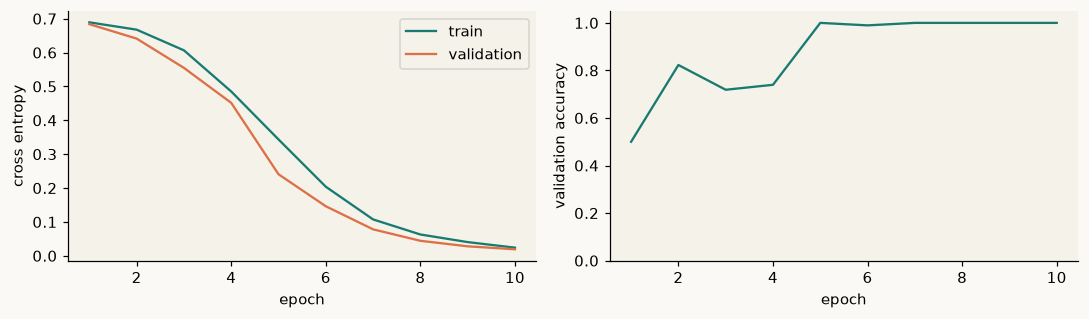

고정 test 192장: accuracy=0.990, CE=0.027


In [9]:
model, history, initial_weights = train_model(x_train, y_train, x_val, y_val, EPOCHS)
show_history(history)
test_result = evaluate(model,x_test,y_test)
print(f"고정 test {len(y_test)}장: accuracy={test_result['accuracy']:.3f}, CE={test_result['loss']:.3f}")

## 5. 학습된 특징을 관찰하기 · 확장 5분
같은 이미지에 대한 첫 층의 학습 전/후 반응을 비교합니다. **밝은 영역은 이 채널의 반응이 크다는 뜻**입니다.
이 그림만으로 “모델이 사람처럼 테두리를 이해했다”거나 “이 채널은 원 뉴런이다”라고 단정하지 않습니다.

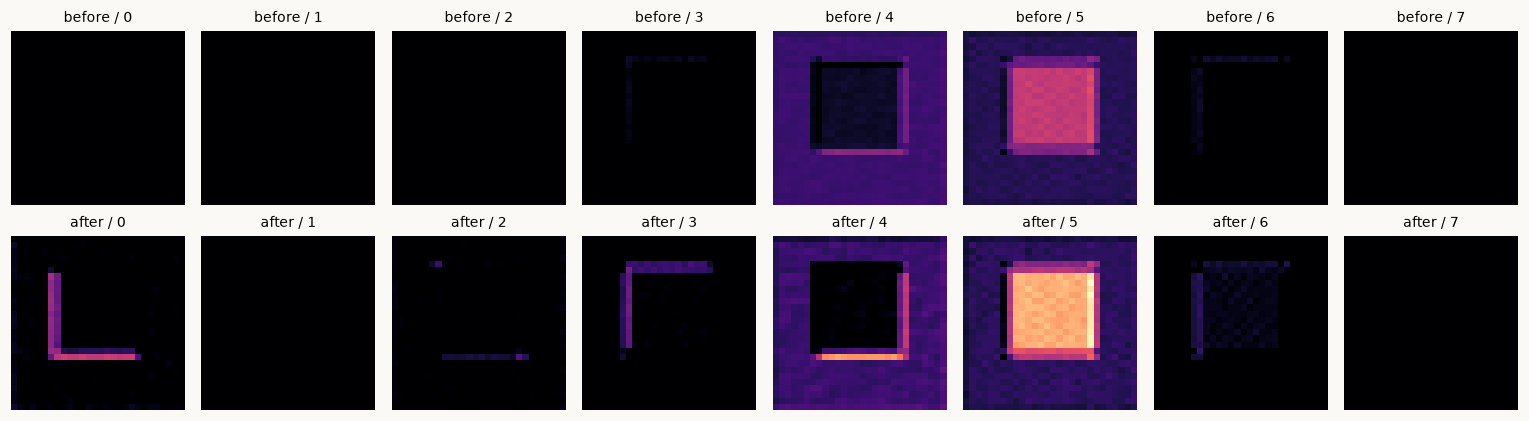

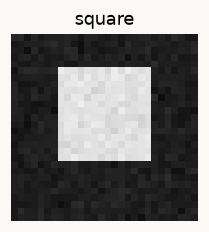

첫 필터 평균 절대 변화: 0.08426839858293533


In [10]:
SAMPLE = 0  # 0~191 중 선택
assert 0 <= SAMPLE < len(x_test)
before_model = SmallCNN(); before_model.load_state_dict(initial_weights); before_model.eval()
with torch.no_grad():
    old_maps = F.relu(before_model.features[0](x_test[SAMPLE:SAMPLE+1]))[0]
    new_maps = F.relu(model.features[0](x_test[SAMPLE:SAMPLE+1]))[0]
fig, axes = plt.subplots(2,8,figsize=(14,4))
limit = max(float(old_maps.max()),float(new_maps.max()),1e-6)
for row, values in enumerate([old_maps,new_maps]):
    for i, ax in enumerate(axes[row]):
        ax.imshow(values[i],cmap='magma',vmin=0,vmax=limit)
        ax.set_title(('before' if row==0 else 'after')+f' / {i}',fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()
gallery(x_test[SAMPLE:SAMPLE+1],y_test[SAMPLE:SAMPLE+1],n=1)
print('첫 필터 평균 절대 변화:', float((model.features[0].weight.detach()-initial_weights['features.0.weight']).abs().mean()))

## 6. 단서를 가리면 어떻게 될까? · 확장 5분
같은 test 물체의 가운데 일부를 배경색으로 가립니다. **예상:** 원과 정사각형의 경계를 모두 지우나요, 일부만 지우나요?
가림은 낯선 입력을 만들기도 하므로 정확도 변화만으로 유일한 원인을 확정하지 않습니다.

원본 정확도: 0.99 | 가림 정확도: 0.5
오분류를 먼저 표시합니다.


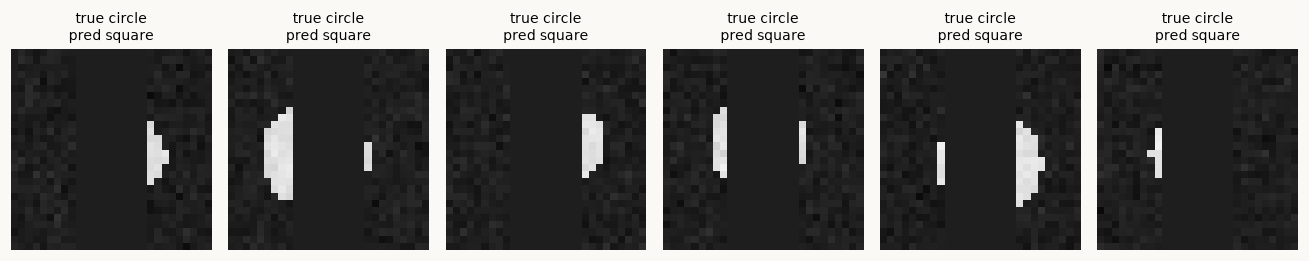

In [11]:
OCCLUSION_WIDTH = 10  # 0~20. 모델은 다시 학습하지 않고 입력만 바꿉니다.
assert 0 <= OCCLUSION_WIDTH <= 20
occluded = x_test.clone()
left = 14-OCCLUSION_WIDTH//2
occluded[:,:,:,left:left+OCCLUSION_WIDTH] = .12
occluded_result = evaluate(model,occluded,y_test)
print('원본 정확도:', round(test_result['accuracy'],3), '| 가림 정확도:', round(occluded_result['accuracy'],3))
pred = occluded_result['logits'].argmax(1)
wrong = torch.where(pred != y_test)[0][:6]
chosen = wrong if len(wrong) else torch.arange(6)
print('오분류를 먼저 표시합니다.' if len(wrong) else '이번 조건에는 오분류가 없어 앞의 6장을 표시합니다.')
gallery(occluded[chosen], titles=[f'true {NAMES[y_test[i]]}\npred {NAMES[pred[i]]}' for i in chosen], n=6)

## 7. 결과를 내 말로 남기기
아래 문자열을 본인의 관찰로 바꿉니다. 출력 파일은 `outputs/week01_concept/`에 저장됩니다.
Colab에서는 왼쪽 파일 패널에서 JSON을 다운로드하거나, 실행 결과를 포함한 ipynb를 다운로드하세요.

In [12]:
reflection = {
    '예상': '실행 전에 예상한 변화를 작성하세요.',
    '관찰': '필터·특징 맵 또는 가림 전후에서 실제로 본 결과를 작성하세요.',
    '설명': '관찰이 내 예상과 같거나 달랐던 이유를 작성하세요.',
    '한계': '이 합성 데이터의 결과로 실제 컵 인식에 대해 말할 수 없는 것을 작성하세요.'}
metrics = {'seed': SEED, 'epochs': EPOCHS, 'test_n': len(y_test),
    'test_accuracy': test_result['accuracy'], 'test_ce': test_result['loss'],
    'occlusion_width': OCCLUSION_WIDTH, 'occluded_accuracy': occluded_result['accuracy']}
out = Path('outputs/week01_concept'); out.mkdir(parents=True,exist_ok=True)
(out/'observations.json').write_text(json.dumps({'metrics':metrics,'reflection':reflection},ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown('\n'.join(f'- **{k}**: {v}' for k,v in reflection.items())))
print('저장:', out/'observations.json')

- **예상**: 실행 전에 예상한 변화를 작성하세요.
- **관찰**: 필터·특징 맵 또는 가림 전후에서 실제로 본 결과를 작성하세요.
- **설명**: 관찰이 내 예상과 같거나 달랐던 이유를 작성하세요.
- **한계**: 이 합성 데이터의 결과로 실제 컵 인식에 대해 말할 수 없는 것을 작성하세요.

저장: outputs\week01_concept\observations.json


### 자율 실험 · 하나만 골라도 좋습니다
1. **필터:** 수평/수직 필터의 부호를 바꾸고 ReLU 전후 차이를 설명하세요. 핵심 2의 셀부터 실행합니다.
2. **가림:** 폭 0·6·12를 비교하고 정확도와 남은 경계를 기록하세요. 6의 셀만 다시 실행합니다.
3. **학습:** epoch 2와 10을 validation으로 비교하세요. 4부터 새 모델로 실행하고, 비교를 정한 뒤 test를 확인합니다.

| 바꾼 변수 | 고정한 조건 | 예상 | 관찰 | 다음 질문 |
|---|---|---|---|---|
| 작성 | 작성 | 작성 | 작성 | 작성 |

**해석 점검:** 수작업 필터와 학습된 필터는 둘 다 숫자로 된 가중치입니다. 밝은 특징 맵은 정답의 증명이 아닙니다.
가림 후 정확도가 유지되더라도 모든 가림에 강하다는 뜻은 아닙니다.

### 출처와 다음 실습
- [PyTorch Conv2d: 채널과 교차상관 연산](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [PyTorch: 손실·역전파·optimizer](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- 다음 주 `concept_practice.ipynb`에서 배경색만 바꾸는 통제 실험을 합니다.
- 실제 이미지로 확장하려면 기존 `practice.ipynb`의 FashionMNIST 실습과 `homework_optional.ipynb`를 사용합니다.